# 03 — Exploratory Data Analysis: Food Security in Nigeria
  
Pipeline: Spatial Heterogeneity → Climate Sensitivity → Smart Lags → Livelihood Zones → Baselines

## 1. Setup & Data Loading

In [1]:
import sys, os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import scipy.stats as stats

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

# ── Paths ──────────────────────────────────────────────────────────────────
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

filepath = os.path.join(project_root, "data", "processed", "NIGERIA_WFP_ENGINEERED.csv")
geo_path = os.path.join(project_root, "geo", "gadm41_NGA_2.json")

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv(filepath)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['NAME_1', 'time']).reset_index(drop=True)

# ── North / South segmentation ─────────────────────────────────────────────
north_states = ['Borno','Kano','Kaduna','Katsina','Sokoto','Kebbi','Zamfara','Jigawa',
                'Yobe','Adamawa','Bauchi','Gombe','Taraba','Niger','Plateau','Nassarawa',
                'Benue','Kogi','Kwara','Federal Capital Territory']
df['geopolitical_region'] = df['NAME_1'].apply(
    lambda x: 'North' if x in north_states else 'South')

print(f"Loaded: {df.shape[0]} obs × {df.shape[1]} columns")
print(f"States: {df['NAME_1'].nunique()} | Period: {df['time'].min().date()} → {df['time'].max().date()}")
print(f"North states: {(df['geopolitical_region']=='North').sum() // df['time'].nunique()} | "
      f"South states: {(df['geopolitical_region']=='South').sum() // df['time'].nunique()}")


Loaded: 1080 obs × 80 columns
States: 30 | Period: 2023-01-01 → 2025-12-01
North states: 19 | South states: 11


## 2. Spatial Distribution of Food Insecurity (Choropleth)

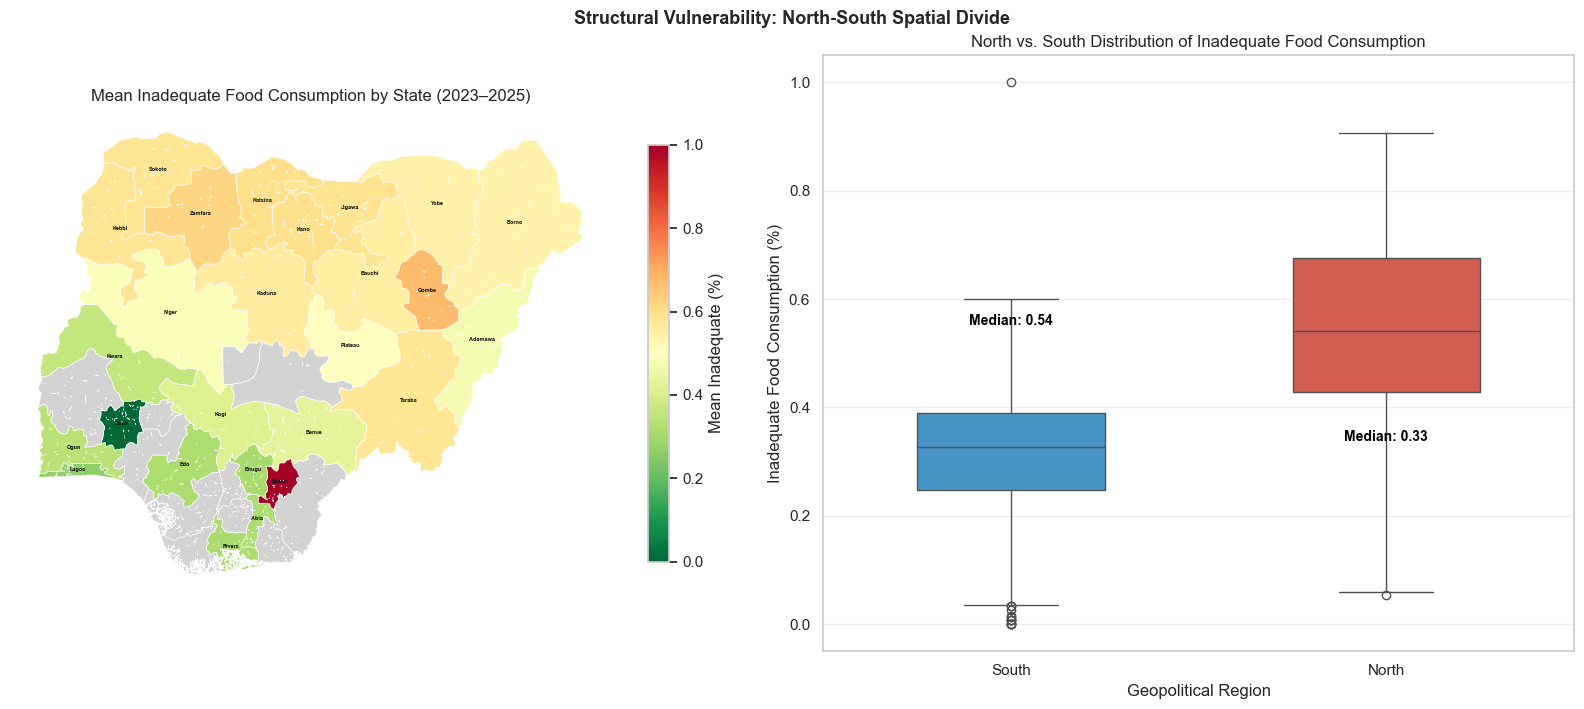

States without WFP data (grey): ['AkwaIbom', 'Anambra', 'Bayelsa', 'CrossRiver', 'Delta', 'Ekiti', 'FederalCapitalTerritory', 'Imo', 'Nasarawa', 'Ondo', 'Oyo']


In [4]:
import geopandas as gpd

# ── Load and dissolve GeoJSON to Admin-1 ──────────────────────────────────
gdf = gpd.read_file(geo_path)

def clean_name(s):
    return str(s).strip().replace('Federal Capital Territory', 'Abuja')

# gadm41_NGA_2 is Admin-2 → dissolve to Admin-1
gdf_adm1 = gdf.dissolve(by='NAME_1').reset_index()[['NAME_1', 'geometry']]
gdf_adm1['NAME_1'] = gdf_adm1['NAME_1'].apply(clean_name)

# Mean inadequate per state for the map
state_avg = df.groupby('NAME_1')['inadequate'].mean().reset_index()
state_avg['NAME_1'] = state_avg['NAME_1'].apply(clean_name)

merged = gdf_adm1.merge(state_avg, on='NAME_1', how='left')

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

merged.plot(column='inadequate', ax=axes[0], cmap='RdYlGn_r',
            edgecolor='white', linewidth=0.5,
            legend=True, legend_kwds={'shrink': 0.7, 'label': 'Mean Inadequate (%)'},
            missing_kwds={'color': 'lightgrey', 'label': 'No WFP data'})

for _, row in merged.iterrows():
    if row.geometry is not None and not pd.isna(row.get('inadequate', np.nan)):
        c = row.geometry.centroid
        axes[0].annotate(row['NAME_1'], xy=(c.x, c.y),
                         fontsize=4, ha='center', color='#111', fontweight='bold')

axes[0].set_title("Mean Inadequate Food Consumption by State (2023–2025)", fontsize=12)
axes[0].axis('off')

# North vs South distribution
sns.boxplot(data=df, x='geopolitical_region', y='inadequate',
            hue='geopolitical_region', palette={'North': '#e74c3c', 'South': '#3498db'},
            width=0.5, ax=axes[1], legend=False)
axes[1].set_title("North vs. South Distribution of Inadequate Food Consumption", fontsize=12)
axes[1].set_xlabel("Geopolitical Region")
axes[1].set_ylabel("Inadequate Food Consumption (%)")
axes[1].grid(axis='y', alpha=0.3)

# Annotate medians
for i, region in enumerate(['North', 'South']):
    med = df[df['geopolitical_region'] == region]['inadequate'].median()
    axes[1].text(i, med + 0.01, f'Median: {med:.2f}',
                 ha='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.suptitle("Structural Vulnerability: North-South Spatial Divide", fontsize=13, fontweight='bold', y=1.01)
plt.show()

missing_states = merged[merged['inadequate'].isna()]['NAME_1'].tolist()
print(f"States without WFP data (grey): {missing_states}")


## 3. Livelihood Zones: Structural Determinants of Hunger

ANOVA — F = 38.56, p = 2.84e-86
→ H0 rejected: livelihood zone explains food insecurity levels.


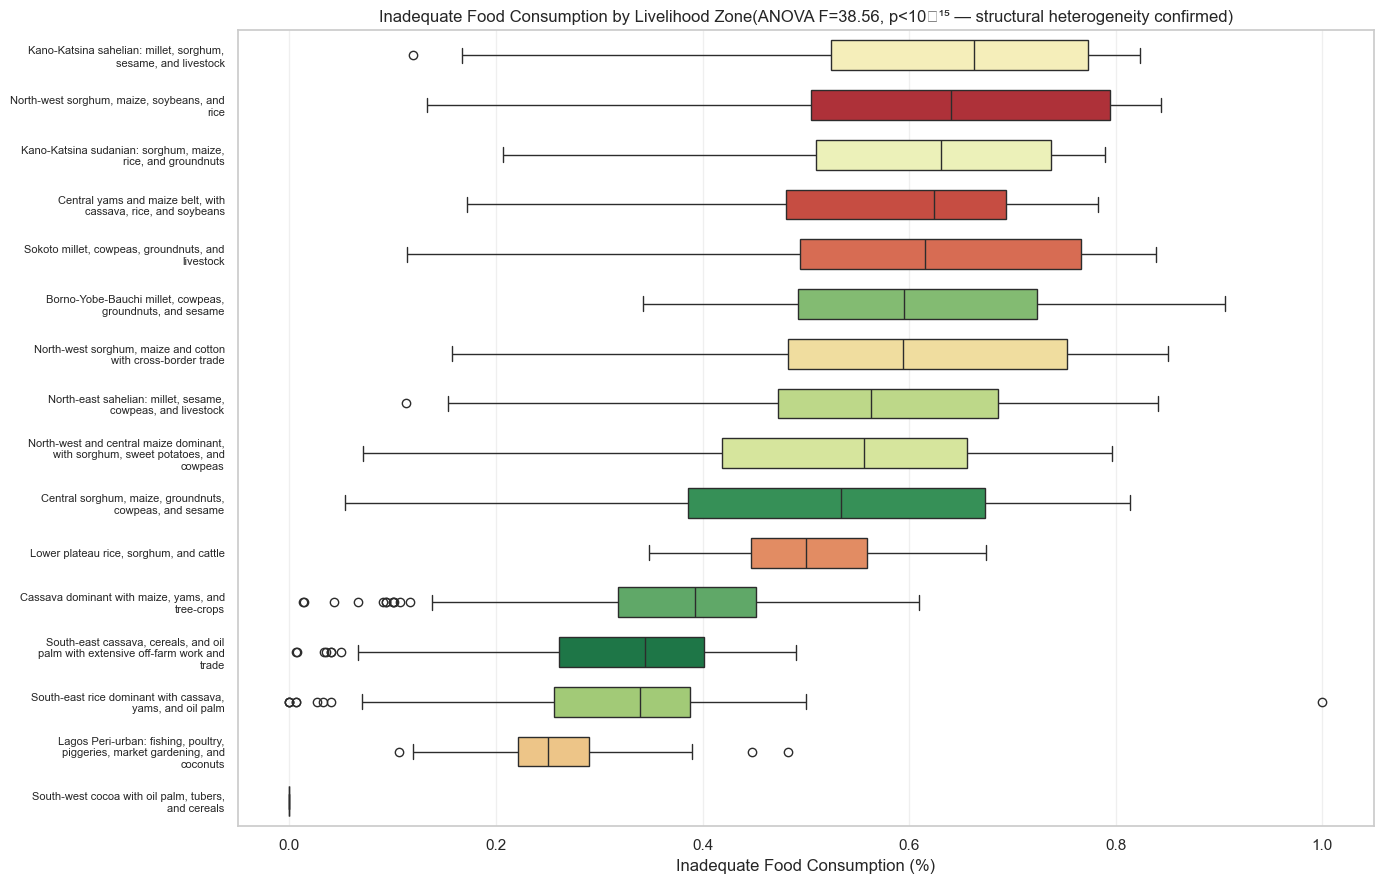

In [5]:
# ── ANOVA + Boxplot ───────────────────────────────────────────────────────
df_lhz = df.dropna(subset=['dominant_livelihood_zone', 'inadequate']).copy()

# ANOVA
groups = [g['inadequate'].values for _, g in df_lhz.groupby('dominant_livelihood_zone')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA — F = {f_stat:.2f}, p = {p_val:.2e}")
print(f"→ {'H0 rejected' if p_val < 0.05 else 'H0 not rejected'}: livelihood zone explains food insecurity levels.")

# Sort zones by median for readability
lhz_order = (df_lhz.groupby('dominant_livelihood_zone')['inadequate']
             .median().sort_values(ascending=False).index.tolist())

import textwrap
labels = [textwrap.fill(l, 40) for l in lhz_order]

fig, ax = plt.subplots(figsize=(14, 9))
sns.boxplot(data=df_lhz, y='dominant_livelihood_zone', x='inadequate',
            order=lhz_order, hue='dominant_livelihood_zone',
            palette='RdYlGn_r', width=0.6, ax=ax, legend=False)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Inadequate Food Consumption by Livelihood Zone"
             f"(ANOVA F={f_stat:.2f}, p<10⁻¹⁵ — structural heterogeneity confirmed)",
             fontsize=12)
ax.set_xlabel("Inadequate Food Consumption (%)")
ax.set_ylabel("")
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Multi-Feature Lagged Correlations (North vs. South)

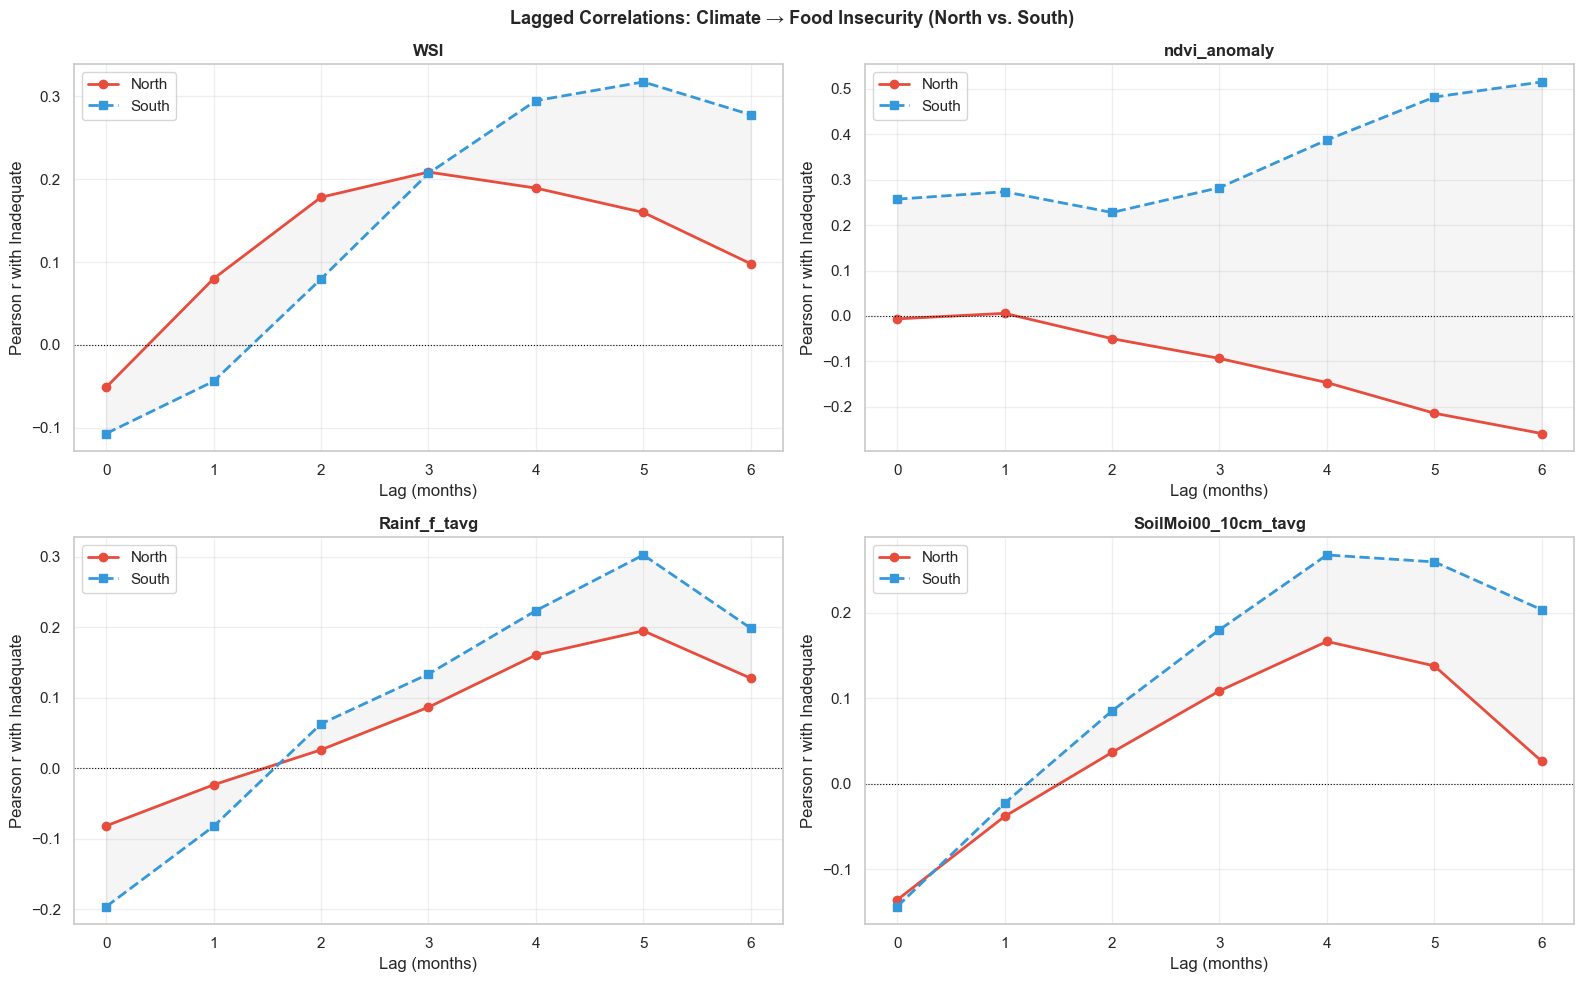

In [12]:
# ── Cross-correlation by region at lags 0–6 ──────────────────────────────
# Pour les variables sans colonnes _Lag_ pré-calculées, on les génère à la volée
features_to_test = ['WSI', 'ndvi_anomaly', 'Rainf_f_tavg', 'SoilMoi00_10cm_tavg']
max_lag = 6

# Calcul des lags à la volée pour chaque variable
df_lagged = df.copy()
for var in features_to_test:
    for lag in range(1, max_lag + 1):
        col = f'{var}_Lag_{lag}'
        if col not in df_lagged.columns:
            df_lagged[col] = df_lagged.groupby('NAME_1')[var].shift(lag)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_test):
    lags = range(max_lag + 1)
    corrs_n, corrs_s = [], []

    for lag in lags:
        col = feature if lag == 0 else f'{feature}_Lag_{lag}'
        r_n = (df_lagged[df_lagged['geopolitical_region'] == 'North'][['inadequate', col]]
               .dropna().corr().iloc[0, 1])
        r_s = (df_lagged[df_lagged['geopolitical_region'] == 'South'][['inadequate', col]]
               .dropna().corr().iloc[0, 1])
        corrs_n.append(r_n)
        corrs_s.append(r_s)

    axes[i].plot(lags, corrs_n, 'o-', color='#e74c3c', linewidth=2,
                 label='North', markersize=6)
    axes[i].plot(lags, corrs_s, 's--', color='#3498db', linewidth=2,
                 label='South', markersize=6)
    axes[i].axhline(0, color='black', lw=0.8, linestyle=':')
    axes[i].fill_between(lags, corrs_n, corrs_s, alpha=0.08, color='grey')
    axes[i].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Lag (months)')
    axes[i].set_ylabel('Pearson r with Inadequate')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_xticks(range(max_lag + 1))

plt.suptitle("Lagged Correlations: Climate → Food Insecurity (North vs. South)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Correlation Matrix (Key Drivers)

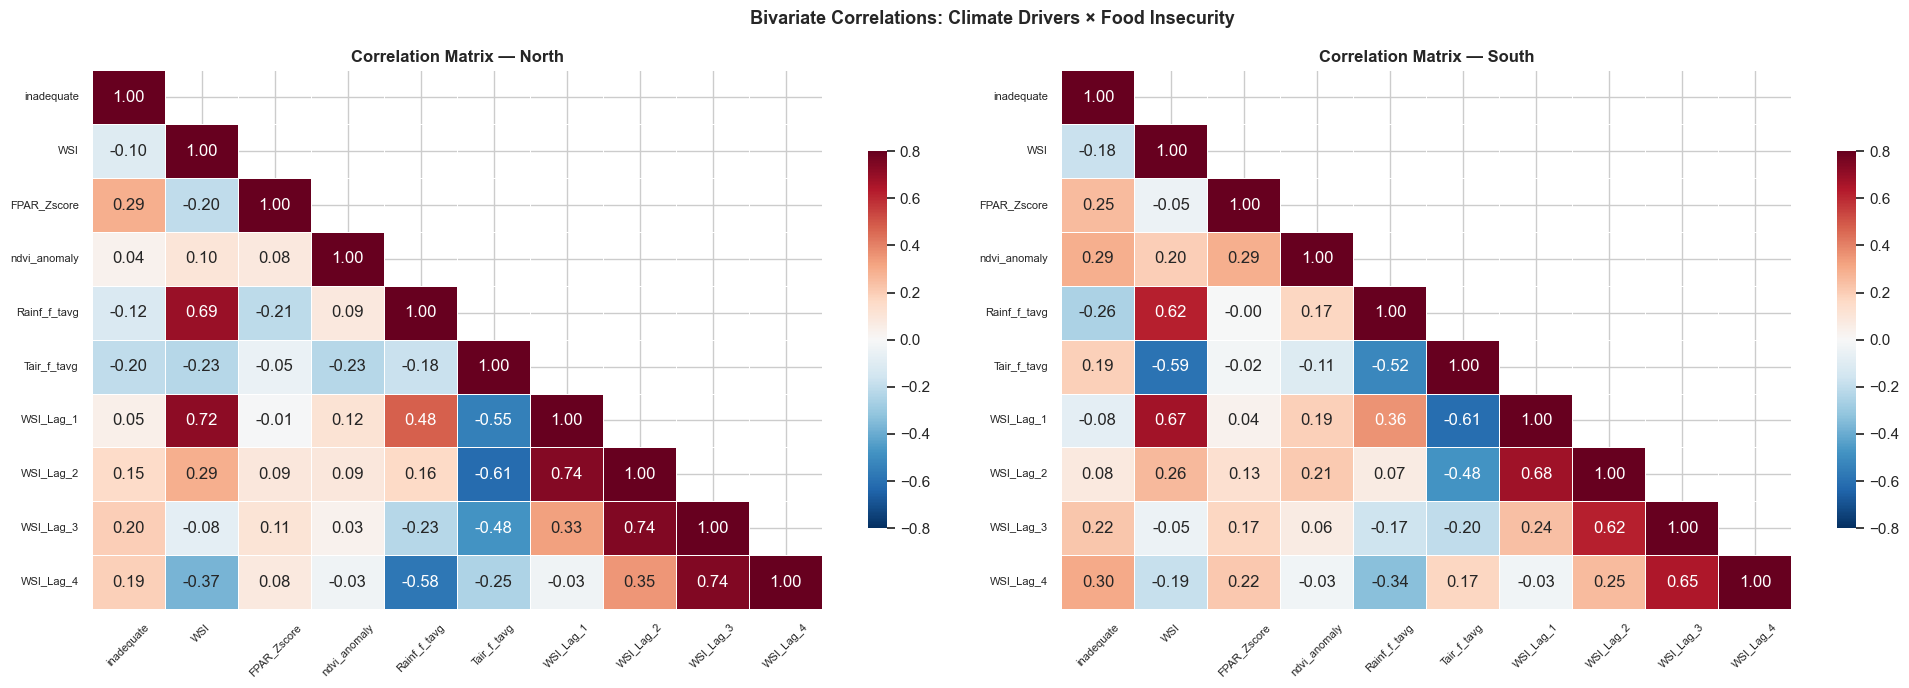

=== Corrélations avec 'inadequate' ===

North:
FPAR_Zscore     0.290
Tair_f_tavg    -0.201
WSI_Lag_3       0.198
WSI_Lag_4       0.189
WSI_Lag_2       0.150
Rainf_f_tavg   -0.122
WSI            -0.102
WSI_Lag_1       0.045
ndvi_anomaly    0.035

South:
WSI_Lag_4       0.301
ndvi_anomaly    0.288
Rainf_f_tavg   -0.256
FPAR_Zscore     0.252
WSI_Lag_3       0.223
Tair_f_tavg     0.193
WSI            -0.178
WSI_Lag_2       0.081
WSI_Lag_1      -0.077


In [14]:
# ── Correlation matrix on selected features ──────────────────────────────
cols_corr = ['inadequate', 'WSI', 'FPAR_Zscore', 'ndvi_anomaly',
             'Rainf_f_tavg', 'Tair_f_tavg',
             'WSI_Lag_1', 'WSI_Lag_2', 'WSI_Lag_3', 'WSI_Lag_4']
cols_corr = [c for c in cols_corr if c in df.columns]

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, region in zip(axes, ['North', 'South']):
    sub  = df[df['geopolitical_region'] == region][cols_corr].dropna()
    corr = sub.corr()

    # Masque: on garde le triangle inférieur SAUF la première ligne
    # pour toujours voir les corrélations avec 'inadequate'
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
                annot=True, fmt='.2f', linewidths=0.4,
                vmin=-0.8, vmax=0.8,
                cbar_kws={'shrink': 0.7})
    ax.set_title(f'Correlation Matrix — {region}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle("Bivariate Correlations: Climate Drivers × Food Insecurity",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Corrélations avec inadequate uniquement ───────────────────────────────
print("=== Corrélations avec 'inadequate' ===")
for region in ['North', 'South']:
    sub = df[df['geopolitical_region'] == region][cols_corr].dropna()
    row = sub.corr()['inadequate'].drop('inadequate').sort_values(key=abs, ascending=False)
    print(f"\n{region}:")
    print(row.round(3).to_string())

### Structural Reading of the Correlation Matrix (North vs. South)

#### 1. WSI — Opposite Signs Across Regions
The most striking result is the **sign reversal of WSI** with `inadequate`:
- **North: r = −0.10** — negative but weak at Lag 0. The signal strengthens progressively
  through lagged values (WSI_Lag_2: +0.15, WSI_Lag_3: +0.20), suggesting a **delayed
  transmission** of water stress to food consumption via stock depletion.
- **South: r = −0.18** at Lag 0, rising to **+0.30 at Lag 4** — a stronger and more
  persistent lagged response, consistent with the multi-cycle vulnerability of root
  crop systems (cassava, yam) to sustained water deficits.

The sign inversion from negative (contemporaneous) to positive (lagged) reflects the
**stock-depletion mechanism**: a water deficit does not cause immediate hunger, but
exhausts household food reserves 2–4 months later.

#### 2. FPAR and the Lean Season Paradox
`FPAR_Zscore` is **positively** correlated with `inadequate` in both regions
(North: +0.29, South: +0.25). This counterintuitive result is the **Lean Season
Paradox**: peak vegetation greenness coincides with the growing season, which is
precisely when household food stocks from the previous harvest are at their lowest.
Hunger peaks *during* the green season, not after it.

#### 3. Temperature: A North-South Divergence
`Tair_f_tavg` exhibits a **sign reversal** across regions:
- **North: r = −0.20** — higher temperatures reduce food insecurity, consistent with
  the positive role of warmth in Sahelian cereal growing conditions.
- **South: r = +0.19** — higher temperatures *increase* food insecurity, driven by
  heat stress on root crops and accelerated spoilage in the absence of cold storage.

This divergence is a critical justification for region-specific modeling.

#### 4. Multicollinearity Within the WSI Lag Chain
The WSI lag structure shows high inter-lag correlations (WSI_Lag_1 / WSI_Lag_2:
r ≈ 0.74 in both regions), confirming strong **temporal autocorrelation** in the
water stress signal. This motivates the LassoCV regularization in Phase 4: without
penalization, including all WSI lags simultaneously would produce unstable,
inflated coefficients. The Lasso selects the single lag with the highest
marginal predictive contribution per state.

#### 5. Rainfall as a Weak Direct Predictor
`Rainf_f_tavg` shows a modest negative correlation with `inadequate`
(North: −0.12, South: −0.26) that **does not strengthen with lags** — confirming
that raw precipitation is a poor direct predictor of food shocks. The WSI, which
integrates precipitation with evapotranspiration and crop water demand, is the
superior signal. This justifies our choice to retain WSI over raw rainfall in the
final feature set.

## 6. Seasonality: Precipitation vs. Food Insecurity

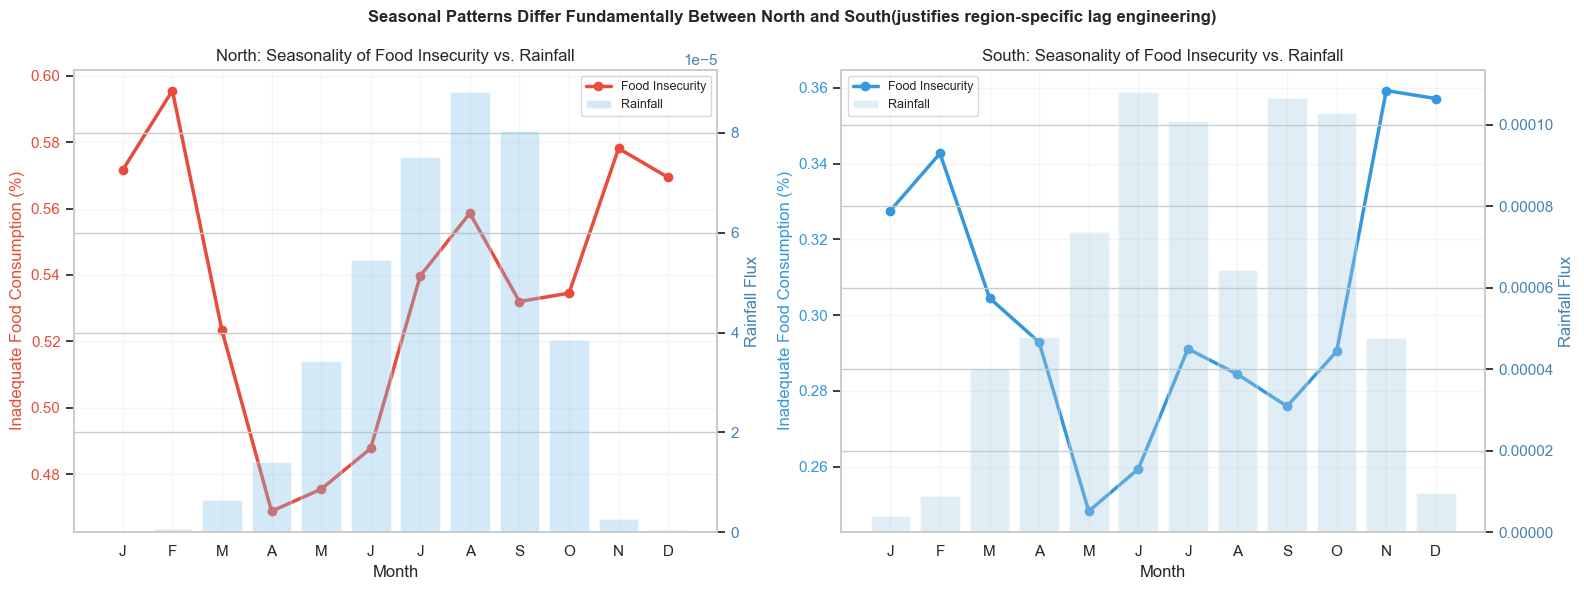

In [16]:
# ── Monthly seasonality split by region ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, region, c1, c2 in zip(axes,
                                ['North', 'South'],
                                ['#e74c3c', '#3498db'],
                                ['#85c1e9', '#a9cce3']):
    sub = df[df['geopolitical_region'] == region].copy()
    sub['month'] = sub['time'].dt.month
    seasonal = sub.groupby('month')[['inadequate', 'Rainf_f_tavg']].mean()

    ax2 = ax.twinx()
    ax.plot(seasonal.index, seasonal['inadequate'], 'o-',
            color=c1, linewidth=2.5, label='Food Insecurity', zorder=3)
    ax2.bar(seasonal.index, seasonal['Rainf_f_tavg'],
            alpha=0.35, color=c2, label='Rainfall')

    ax.set_xlabel('Month')
    ax.set_ylabel('Inadequate Food Consumption (%)', color=c1)
    ax.tick_params(axis='y', labelcolor=c1)
    ax2.set_ylabel('Rainfall Flux', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_title(f'{region}: Seasonality of Food Insecurity vs. Rainfall', fontsize=12)
    ax.grid(alpha=0.2)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.suptitle("Seasonal Patterns Differ Fundamentally Between North and South"
             "(justifies region-specific lag engineering)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. State-Specific Smart Lags

In [17]:
def analyze_optimal_lag(df, state_name, target_var='inadequate',
                        climate_var='WSI', max_lag=6, plot=False):
    col_state = 'NAME_1' if 'NAME_1' in df.columns else 'ADM1_NAME'
    df_state  = df[df[col_state] == state_name].sort_values('time').copy()
    if df_state.empty:
        return None

    lags, corrs = list(range(max_lag + 1)), []
    for lag in lags:
        col_name = climate_var if lag == 0 else f'{climate_var}_Lag_{lag}'
        if col_name in df_state.columns:
            valid = df_state[[target_var, col_name]].dropna()
            corrs.append(valid[target_var].corr(valid[col_name]) if len(valid) > 2 else 0)
        else:
            corrs.append(0)

    best_idx  = int(np.argmax([abs(c) for c in corrs]))
    best_lag  = lags[best_idx]
    best_corr = corrs[best_idx]

    if plot:
        fig, ax1 = plt.subplots(figsize=(12, 5))
        ax1.plot(df_state['time'], df_state[target_var],
                 color='tab:red', linewidth=2, label='Food Insecurity')
        ax1.set_ylabel('Inadequate Food Consumption (%)', color='tab:red')
        ax1.tick_params(axis='y', labelcolor='tab:red')
        ax2 = ax1.twinx()
        best_col = climate_var if best_lag == 0 else f'{climate_var}_Lag_{best_lag}'
        ax2.fill_between(df_state['time'], df_state[best_col],
                         color='tab:blue', alpha=0.25,
                         label=f'{climate_var} (Lag {best_lag})')
        ax2.set_ylabel(f'{climate_var} at Lag {best_lag}', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
        plt.title(f'{state_name}: {climate_var} (Lag {best_lag}) | r = {best_corr:.3f}')
        fig.tight_layout(); plt.show()

    return {'state': state_name, 'best_lag': best_lag, 'correlation': best_corr}

# ── Compute for all variables × states ────────────────────────────────────
climate_features = [
    'Evap_tavg', 'Rainf_f_tavg', 'Tair_f_tavg', 'Qair_f_tavg', 'Wind_f_tavg',
    'SoilMoi40_100cm_tavg', 'WSI', 'soil_anomaly', 'rain_anomaly', 'ndvi_anomaly'
]

lag_results = []
for var in climate_features:
    for state in df['NAME_1'].unique():
        res = analyze_optimal_lag(df, state, climate_var=var, plot=False)
        if res:
            res['variable'] = var
            lag_results.append(res)

df_all_lags = pd.DataFrame(lag_results)

top_drivers = (df_all_lags.groupby('variable')['correlation']
               .agg(lambda x: x.abs().mean())
               .sort_values(ascending=False))
print("=== Top Climate Drivers (mean |r| across all states) ===")
print(top_drivers.round(3).to_string())

best_row = df_all_lags.loc[df_all_lags['correlation'].abs().idxmax()]
print(f"\n→ Strongest signal: {best_row['state']} | {best_row['variable']} | "
      f"Lag {best_row['best_lag']} | r = {best_row['correlation']:.3f}")


=== Top Climate Drivers (mean |r| across all states) ===
variable
WSI                     0.341
Tair_f_tavg             0.229
soil_anomaly            0.181
ndvi_anomaly            0.176
SoilMoi40_100cm_tavg    0.162
Wind_f_tavg             0.149
rain_anomaly            0.142
Rainf_f_tavg            0.128
Evap_tavg               0.111
Qair_f_tavg             0.108

→ Strongest signal: Adamawa | WSI | Lag 3 | r = 0.584


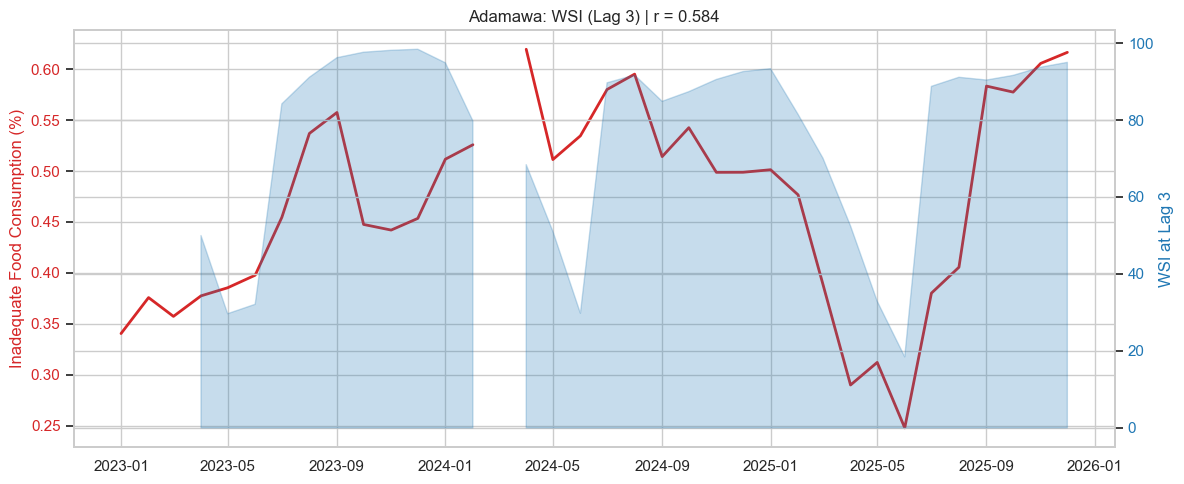

{'state': 'Adamawa',
 'best_lag': 3,
 'correlation': np.float64(0.5840439892418179)}

In [18]:
# ── Flagship example: Adamawa WSI ────────────────────────────────────────
analyze_optimal_lag(df, 'Adamawa', climate_var='WSI', plot=True)


## 8. Distribution of Optimal Lags (Why State-Specific Lags?)

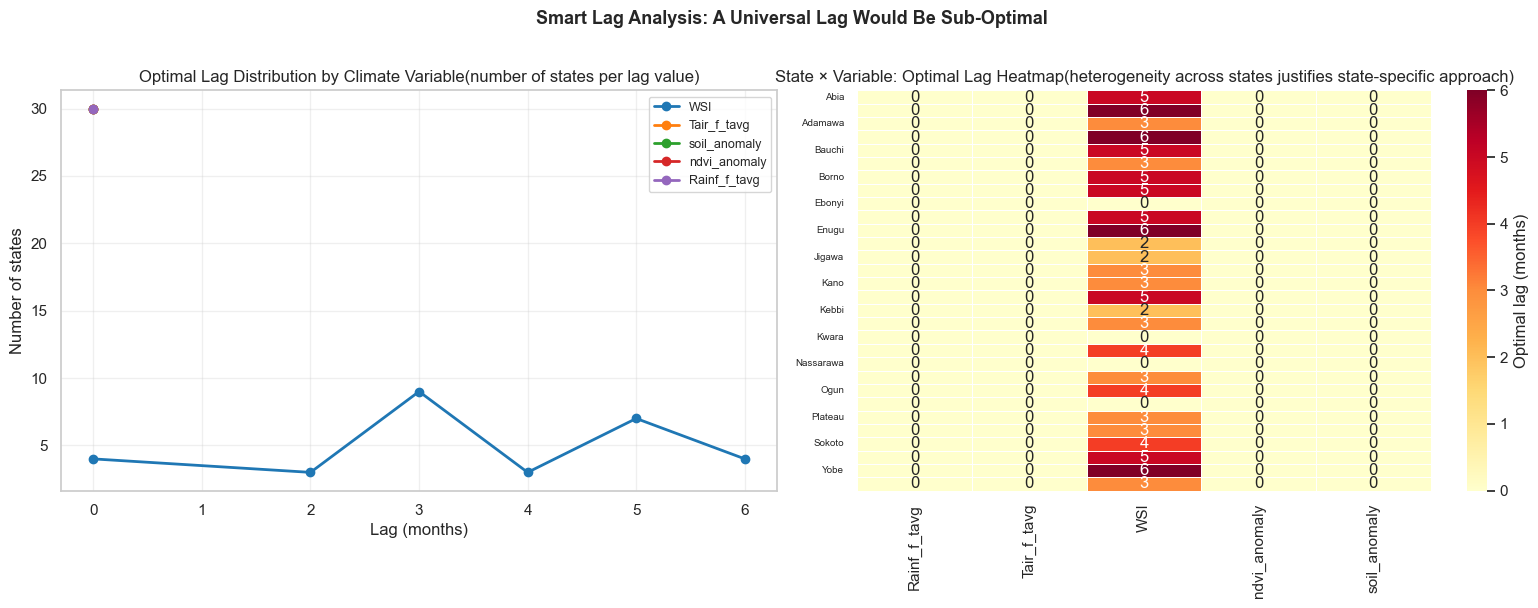

WSI optimal lag distribution across states:
best_lag
0    4
2    3
3    9
4    3
5    7
6    4

→ 26/30 states have optimal WSI lag > 0
  A universal lag=0 would misalign the signal for the majority of states.


In [22]:
# ── Plot 1: lag frequency per variable ───────────────────────────────────
top_vars = ['WSI', 'Tair_f_tavg', 'soil_anomaly', 'ndvi_anomaly', 'Rainf_f_tavg']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette_vars = sns.color_palette("tab10", len(top_vars))
lag_counts = (df_all_lags.groupby(['variable', 'best_lag'])
              .size().reset_index(name='n_states'))

for i, var in enumerate(top_vars):
    sub = lag_counts[lag_counts['variable'] == var]
    axes[0].plot(sub['best_lag'], sub['n_states'],
                 marker='o', label=var, color=palette_vars[i], linewidth=2)

axes[0].set_title("Optimal Lag Distribution by Climate Variable""(number of states per lag value)", fontsize=12)
axes[0].set_xlabel("Lag (months)")
axes[0].set_ylabel("Number of states")
axes[0].set_xticks(range(7))
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── Plot 2: heatmap states × variable → lag ───────────────────────────────
pivot = (df_all_lags[df_all_lags['variable'].isin(top_vars)]
         .pivot_table(index='state', columns='variable', values='best_lag'))

sns.heatmap(pivot, ax=axes[1], cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'label': 'Optimal lag (months)'})
axes[1].set_title("State × Variable: Optimal Lag Heatmap"
                  "(heterogeneity across states justifies state-specific approach)", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle("Smart Lag Analysis: A Universal Lag Would Be Sub-Optimal",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
wsi_lags = df_all_lags[df_all_lags['variable'] == 'WSI']
print("WSI optimal lag distribution across states:")
print(wsi_lags['best_lag'].value_counts().sort_index().to_string())
n_nonzero = (wsi_lags['best_lag'] > 0).sum()
print(f"\n→ {n_nonzero}/{len(wsi_lags)} states have optimal WSI lag > 0")
print("  A universal lag=0 would misalign the signal for the majority of states.")


## 9. Climate Sensitivity Choropleth

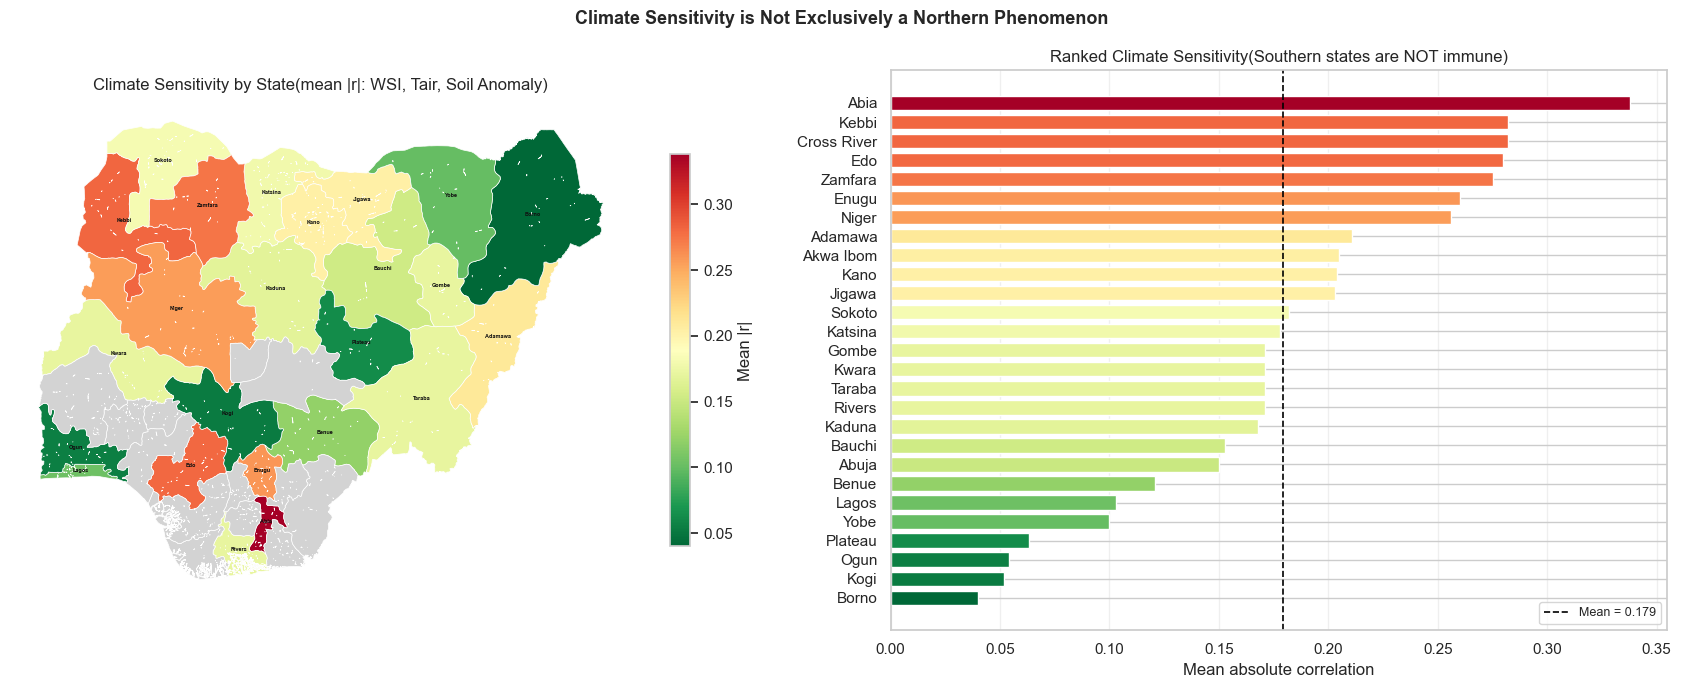

Top 5 most climate-sensitive states:
     NAME_1  sensitivity
       Abia        0.338
Cross River        0.282
      Kebbi        0.282
        Edo        0.280
    Zamfara        0.275

Bottom 5:
 NAME_1  sensitivity
   Yobe        0.100
Plateau        0.063
   Ogun        0.054
   Kogi        0.052
  Borno        0.040


In [25]:
# ── Compute sensitivity = mean |r| over top 3 drivers ────────────────────
top_3 = ['WSI', 'Tair_f_tavg', 'soil_anomaly']
sens_rows = []
for state in df['NAME_1'].unique():
    sub = df[df['NAME_1'] == state][['inadequate'] + top_3].dropna()
    if len(sub) > 5:
        r = sub.corr()['inadequate'].drop('inadequate').abs().mean()
        sens_rows.append({'NAME_1': state, 'sensitivity': round(r, 3)})

df_sens = pd.DataFrame(sens_rows)

# ── Merge with geodata ────────────────────────────────────────────────────
gdf_s = gdf_adm1.copy()
df_sens['NAME_1'] = df_sens['NAME_1'].apply(lambda s: s.strip().replace('Federal Capital Territory','Abuja'))
merged_sens = gdf_s.merge(df_sens, on='NAME_1', how='left')

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

vmin, vmax = df_sens['sensitivity'].min(), df_sens['sensitivity'].max()
cmap_s = 'RdYlGn_r'

merged_sens.plot(column='sensitivity', ax=axes[0], cmap=cmap_s,
                 vmin=vmin, vmax=vmax, edgecolor='white', linewidth=0.5,
                 legend=True, legend_kwds={'shrink': 0.7, 'label': 'Mean |r|'},
                 missing_kwds={'color': 'lightgrey'})

for _, row in merged_sens.iterrows():
    if row.geometry is not None and not pd.isna(row.get('sensitivity', np.nan)):
        c = row.geometry.centroid
        axes[0].annotate(row['NAME_1'], xy=(c.x, c.y),
                         fontsize=4, ha='center', color='#111', fontweight='bold')

axes[0].set_title("Climate Sensitivity by State(mean |r|: WSI, Tair, Soil Anomaly)", fontsize=12)
axes[0].axis('off')

# Ranked bar chart
df_sorted = df_sens.sort_values('sensitivity', ascending=True)
norm_ = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap_ = plt.cm.get_cmap(cmap_s)
bar_colors = [cmap_(norm_(v)) for v in df_sorted['sensitivity']]

axes[1].barh(df_sorted['NAME_1'], df_sorted['sensitivity'],
             color=bar_colors, edgecolor='white', height=0.75)
axes[1].axvline(df_sens['sensitivity'].mean(), color='black', linestyle='--', lw=1.2,
                label=f"Mean = {df_sens['sensitivity'].mean():.3f}")
axes[1].set_title("Ranked Climate Sensitivity"
                  "(Southern states are NOT immune)", fontsize=12)
axes[1].set_xlabel("Mean absolute correlation")
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("Climate Sensitivity is Not Exclusively a Northern Phenomenon",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5 most climate-sensitive states:")
print(df_sens.sort_values('sensitivity', ascending=False).head(5).to_string(index=False))
print("\nBottom 5:")
print(df_sens.sort_values('sensitivity', ascending=False).tail(5).to_string(index=False))


## 10. State-Level Dashboard

=== Top 10 States by Mean Food Insecurity ===
         Mean_Inadequate  Volatility  Peak_Max  Mean_WSI  Mean_Soil_Anomaly
NAME_1                                                                     
Ebonyi             1.000         NaN     1.000    89.037                NaN
Gombe              0.672       0.135     0.906    73.903               -0.0
Zamfara            0.617       0.199     0.844    67.867                0.0
Katsina            0.601       0.204     0.823    65.955               -0.0
Kano               0.599       0.158     0.790    65.541                0.0
Jigawa             0.586       0.194     0.841    64.102                0.0
Kebbi              0.583       0.192     0.851    69.207               -0.0
Sokoto             0.583       0.225     0.838    59.517                0.0
Taraba             0.581       0.156     0.783    75.551               -0.0
Kaduna             0.564       0.138     0.796    74.728               -0.0


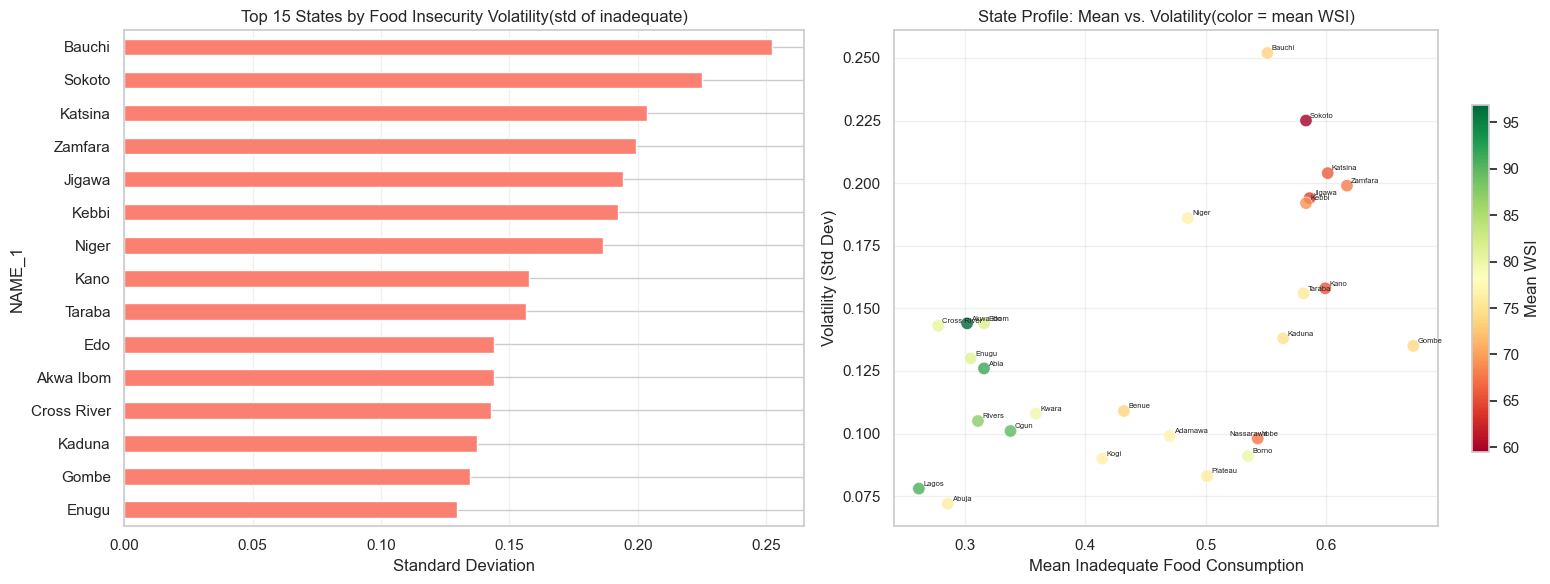

In [28]:
# ── Volatility ranking ────────────────────────────────────────────────────
state_volatility = df.groupby('NAME_1')['inadequate'].std().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_volatility.head(15).plot(kind='barh', color='salmon', ax=axes[0])
axes[0].invert_yaxis()
axes[0].set_title("Top 15 States by Food Insecurity Volatility(std of inadequate)", fontsize=12)
axes[0].set_xlabel("Standard Deviation")
axes[0].grid(axis='x', alpha=0.3)

# State stats table (top 10 by mean)
state_stats = df.groupby('NAME_1').agg(
    Mean_Inadequate   = ('inadequate', 'mean'),
    Volatility        = ('inadequate', 'std'),
    Peak_Max          = ('inadequate', 'max'),
    Mean_WSI          = ('WSI',        'mean'),
    Mean_Soil_Anomaly = ('soil_anomaly','mean'),
).round(3).sort_values('Mean_Inadequate', ascending=False)

print("=== Top 10 States by Mean Food Insecurity ===")
print(state_stats.head(10).to_string())

# Scatter: mean insecurity vs volatility
axes[1].scatter(state_stats['Mean_Inadequate'], state_stats['Volatility'],
                c=state_stats['Mean_WSI'], cmap='RdYlGn',
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

for state, row in state_stats.iterrows():
    axes[1].annotate(state, (row['Mean_Inadequate'], row['Volatility']),
                     fontsize=5.5, xytext=(3, 2), textcoords='offset points')

sm2 = plt.cm.ScalarMappable(cmap='RdYlGn',
      norm=mcolors.Normalize(vmin=state_stats['Mean_WSI'].min(),
                              vmax=state_stats['Mean_WSI'].max()))
sm2.set_array([])
plt.colorbar(sm2, ax=axes[1], shrink=0.7, label='Mean WSI')
axes[1].set_title("State Profile: Mean vs. Volatility(color = mean WSI)", fontsize=12)
axes[1].set_xlabel("Mean Inadequate Food Consumption")
axes[1].set_ylabel("Volatility (Std Dev)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 11. Naive Seasonal Baseline

=== Naive Seasonal Baseline (y_t = y_{t-12}) ===
Global MAE  : 0.1850
Global RMSE : 0.2403
MAE North   : 0.2059
MAE South   : 0.1418

→ This is the reference floor for the XGBoost model in notebook 04.


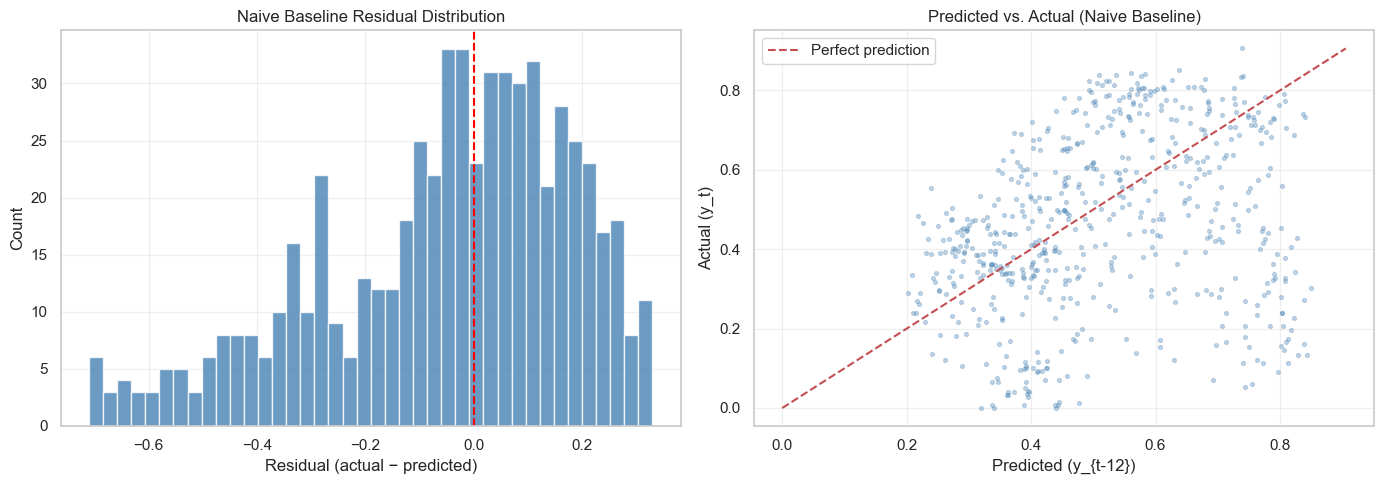

In [29]:
# ── Naive baseline: predict y_{t-12} ─────────────────────────────────────
df['baseline_pred'] = df.groupby('NAME_1')['inadequate'].shift(12)

eval_df = df.dropna(subset=['inadequate', 'baseline_pred'])

mae_global  = mean_absolute_error(eval_df['inadequate'], eval_df['baseline_pred'])
rmse_global = np.sqrt(mean_squared_error(eval_df['inadequate'], eval_df['baseline_pred']))

mae_north = mean_absolute_error(
    eval_df[eval_df['geopolitical_region']=='North']['inadequate'],
    eval_df[eval_df['geopolitical_region']=='North']['baseline_pred'])
mae_south = mean_absolute_error(
    eval_df[eval_df['geopolitical_region']=='South']['inadequate'],
    eval_df[eval_df['geopolitical_region']=='South']['baseline_pred'])

print("=== Naive Seasonal Baseline (y_t = y_{t-12}) ===")
print(f"Global MAE  : {mae_global:.4f}")
print(f"Global RMSE : {rmse_global:.4f}")
print(f"MAE North   : {mae_north:.4f}")
print(f"MAE South   : {mae_south:.4f}")
print("\n→ This is the reference floor for the XGBoost model in notebook 04.")

# ── Plot: residuals ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = eval_df['inadequate'] - eval_df['baseline_pred']
axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', lw=1.5, linestyle='--')
axes[0].set_title("Naive Baseline Residual Distribution", fontsize=12)
axes[0].set_xlabel("Residual (actual − predicted)")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

axes[1].scatter(eval_df['baseline_pred'], eval_df['inadequate'],
                alpha=0.3, s=8, color='steelblue')
lims = [eval_df['inadequate'].min(), eval_df['inadequate'].max()]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_title("Predicted vs. Actual (Naive Baseline)", fontsize=12)
axes[1].set_xlabel("Predicted (y_{t-12})")
axes[1].set_ylabel("Actual (y_t)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
